# Calibration of the final model

The Top-K analysis showed the final CatBoost model ranks inspections usefully by risk. This notebook asks a different question: are the actual predicted probabilities trustworthy as probabilities, or is the model mainly good for ranking? No changes to the model, features, split, or threshold here, this is diagnostic only.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from catboost import CatBoostClassifier
from sklearn.metrics import average_precision_score, roc_auc_score, brier_score_loss, log_loss
from sklearn.calibration import calibration_curve

## Rebuild the 15-feature set and the fixed final model (unchanged)

In [2]:
pred = pd.read_csv("../outputs/prediction_events_current_v1.csv",
                    parse_dates=["inspectionDate", "prev_inspectionDate"], low_memory=False)
long = pd.read_csv("../outputs/inspection_level_longitudinal.csv",
                    parse_dates=["inspectionDate"], low_memory=False)
long = long.sort_values(["estId", "inspectionDate"]).reset_index(drop=True)
long["is_non_pass"] = long["inspectionStatus"].isin(["Conditional Pass", "Closed"]).astype(int)

def rolling_window(g, days, prefix):
    g = g.reset_index()
    dates = g["inspectionDate"].values.astype("datetime64[D]")
    total_infr = g["n_infractions"].to_numpy()
    crucial = g["n_crucial"].to_numpy()
    non_pass = g["is_non_pass"].to_numpy()

    cs_infr = np.concatenate([[0], np.cumsum(total_infr)])
    cs_crucial = np.concatenate([[0], np.cumsum(crucial)])
    cs_nonpass = np.concatenate([[0], np.cumsum(non_pass)])

    lower_edge = dates - np.timedelta64(days, "D")
    low_idx = np.searchsorted(dates, lower_edge, side="left")

    idx_arr = np.arange(len(g))
    return pd.DataFrame({
        "orig_index": g["index"],
        f"{prefix}_n_inspections": idx_arr - low_idx,
        f"{prefix}_n_non_pass": cs_nonpass[idx_arr] - cs_nonpass[low_idx],
        f"{prefix}_total_infractions": cs_infr[idx_arr] - cs_infr[low_idx],
        f"{prefix}_crucial_infractions": cs_crucial[idx_arr] - cs_crucial[low_idx],
    })

rolled_730 = long.groupby("estId", group_keys=False).apply(rolling_window, days=730, prefix="prior_730d").set_index("orig_index")
long_feat = long.join(rolled_730)

hist_730 = long_feat[["estId", "inspectionDate", "prior_730d_n_inspections", "prior_730d_n_non_pass",
                       "prior_730d_total_infractions", "prior_730d_crucial_infractions"]]

df = pred.merge(hist_730, on=["estId", "inspectionDate"], how="left")
assert len(df) == len(pred)

BASE = ["days_since_previous_inspection", "prev_non_pass", "prev_total_infractions",
        "prev_minor", "prev_significant", "prev_crucial", "n_inspections_seen_so_far"]
HIST365 = ["prior_365d_n_inspections", "prior_365d_n_non_pass",
           "prior_365d_total_infractions", "prior_365d_crucial_infractions"]
HIST730 = ["prior_730d_n_inspections", "prior_730d_n_non_pass",
           "prior_730d_total_infractions", "prior_730d_crucial_infractions"]
FEATURES = BASE + HIST365 + HIST730
assert len(FEATURES) == 15

## Strict temporal split, unchanged

In [3]:
df = df.sort_values("inspectionDate").reset_index(drop=True)

unique_dates = np.sort(df["inspectionDate"].unique())
n_dates = len(unique_dates)
train_cut = unique_dates[int(n_dates * 0.70)]
val_cut = unique_dates[int(n_dates * 0.85)]

train = df[df["inspectionDate"] < train_cut].copy()
test = df[df["inspectionDate"] >= val_cut].copy()

assert len(train) == 45334
assert len(test) == 12692
assert train["inspectionDate"].max() < test["inspectionDate"].min()
print("train 45,334 rows, test 12,692 rows,", test["inspectionDate"].min().date(), "to", test["inspectionDate"].max().date())

train 45,334 rows, test 12,692 rows, 2026-04-10 to 2026-09-08


## Retrain the fixed final model, reproduce test predictions

In [4]:
X_train, y_train = train[FEATURES], train["target"]
X_test, y_test = test[FEATURES], test["target"]

model = CatBoostClassifier(
    iterations=300, depth=4, learning_rate=0.05, loss_function="Logloss",
    auto_class_weights="Balanced", random_seed=42, verbose=False,
)
model.fit(X_train, y_train)
test_proba = model.predict_proba(X_test)[:, 1]

test_pr_auc = average_precision_score(y_test, test_proba)
test_roc_auc = roc_auc_score(y_test, test_proba)
print("test PR-AUC:", round(test_pr_auc, 4), "(expect ~0.174)")
print("test ROC-AUC:", round(test_roc_auc, 4), "(expect ~0.734)")

test PR-AUC: 0.1742 (expect ~0.174)
test ROC-AUC: 0.7337 (expect ~0.734)


## Brier score and log loss

Both measure how close the raw predicted probabilities are to the actual outcomes, not just whether the ranking is correct. Calculated directly on `test_proba`, no clipping, rescaling, or recalibration.

In [5]:
test_brier = brier_score_loss(y_test, test_proba)
test_log_loss = log_loss(y_test, test_proba)
test_prevalence = y_test.mean()

print("Brier score:", round(test_brier, 4))
print("log loss:", round(test_log_loss, 4))
print("test Non-Pass prevalence:", round(test_prevalence, 4))

Brier score: 0.2052
log loss: 0.5982
test Non-Pass prevalence: 0.0752


These numbers alone don't say much in isolation, they need the reliability diagram to be interpretable.

## Reliability diagram

10 quantile-based bins (equal-sized groups by predicted probability), the standard `sklearn.calibration.calibration_curve` approach. Only one binning method is used, no comparison-shopping between strategies.

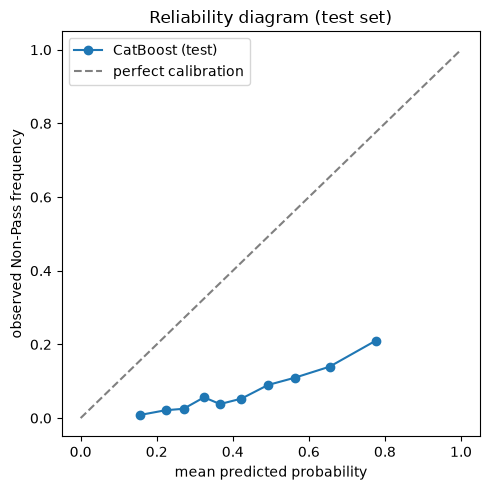

In [6]:
prob_true, prob_pred = calibration_curve(y_test, test_proba, n_bins=10, strategy="quantile")

plt.figure(figsize=(5, 5))
plt.plot(prob_pred, prob_true, marker="o", label="CatBoost (test)")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="perfect calibration")
plt.xlabel("mean predicted probability")
plt.ylabel("observed Non-Pass frequency")
plt.title("Reliability diagram (test set)")
plt.legend()
plt.tight_layout()
plt.savefig("../outputs/figures/catboost_calibration_curve.png", dpi=100)
plt.show()

## Calibration-bin table

In [7]:
bins = pd.qcut(test_proba, q=10, duplicates="drop")
bin_df = pd.DataFrame({"proba": test_proba, "target": y_test.to_numpy(), "bin": bins})

calib_table = bin_df.groupby("bin").agg(
    mean_predicted_probability=("proba", "mean"),
    observed_non_pass_rate=("target", "mean"),
    n_observations=("target", "size"),
).reset_index(drop=True)
calib_table.insert(0, "bin", range(1, len(calib_table) + 1))
calib_table

,bin,mean_predicted_probability,observed_non_pass_rate,n_observations
0,1,0.157238,0.008661,1270
1,2,0.223209,0.021277,1269
2,3,0.270676,0.025217,1269
3,4,0.324511,0.056382,1277
4,5,0.366384,0.038065,1261
5,6,0.422813,0.052797,1269
6,7,0.492610,0.089835,1269
7,8,0.562870,0.109535,1269
8,9,0.654391,0.139480,1269
9,10,0.776010,0.210236,1270


In [8]:
assert calib_table["n_observations"].sum() == 12692
print("all 12,692 test rows accounted for across the 10 bins")

all 12,692 test rows accounted for across the 10 bins


Every single bin shows the same pattern: the mean predicted probability is well above the observed Non-Pass rate. In the lowest bin, predicted probability averages 0.157 but the observed rate is 0.9%. In the highest bin, predicted probability averages 0.776 but the observed rate is only 21.0%. The model consistently overestimates Non-Pass probability, and the gap gets larger, not smaller, in the higher-risk bins.

This is a plausible, expected side effect of `auto_class_weights="Balanced"`: that setting reweights the training loss as if Pass and Non-Pass were equally common, which pushes predicted probabilities toward the middle of the range even though the true base rate is around 7.5%. It's a reasonable explanation, not something re-tested here, since doing so would mean changing the model, which this notebook isn't allowed to do.

## Optional decile table

Same idea as the calibration bins above, sorted into 10 equal-sized groups by predicted probability rank rather than by probability value. This should look similar to the calibration table since both use 10 quantile groups, included mainly as a simple cross-check.

In [9]:
test_sorted = test.assign(proba=test_proba).sort_values("proba").reset_index(drop=True)
test_sorted["decile"] = pd.qcut(test_sorted.index, q=10, labels=False) + 1

decile_table = test_sorted.groupby("decile").agg(
    mean_predicted_probability=("proba", "mean"),
    observed_non_pass_rate=("target", "mean"),
).reset_index()
decile_table

,decile,mean_predicted_probability,observed_non_pass_rate
0,1,0.157238,0.008661
1,2,0.223209,0.021277
2,3,0.270676,0.025217
3,4,0.324367,0.055950
4,5,0.366264,0.038613
5,6,0.422813,0.052797
6,7,0.492610,0.089835
7,8,0.562870,0.109535
8,9,0.654391,0.139480
9,10,0.776010,0.210236


Same pattern as the calibration table: higher deciles do have higher observed Non-Pass rates (0.9% in decile 1 up to 21.0% in decile 10), confirming the ranking is doing something real, it's just that the predicted probability values themselves run well above those observed rates throughout.

## Save results

In [10]:
results = pd.DataFrame([{
    "model": "catboost_tuned_final", "test_brier_score": test_brier, "test_log_loss": test_log_loss,
    "test_pr_auc": test_pr_auc, "test_roc_auc": test_roc_auc, "test_prevalence": test_prevalence,
}])
results.to_csv("../outputs/calibration_results.csv", index=False)

calib_table.to_csv("../outputs/calibration_bins.csv", index=False)

print("saved outputs/calibration_results.csv")
print("saved outputs/calibration_bins.csv")

saved outputs/calibration_results.csv
saved outputs/calibration_bins.csv


## Interpretation

The reliability diagram is not close to the diagonal, the model's predicted probabilities are consistently and substantially higher than the observed Non-Pass frequencies at every level, with the gap widening in the higher-probability bins. This is systematic overprediction, not random noise around the ideal line.

At the same time, the decile table shows predicted probability and observed rate move in the same direction, higher predicted risk really does correspond to a higher observed Non-Pass rate. Combined with the Top-K result from the previous notebook (top 10% by predicted risk captures 28% of actual Non-Pass cases), this points to a clear, precise conclusion: **the model has useful risk-ranking ability, but its raw probabilities should not be interpreted as literal probabilities** ("a 70% chance of Non-Pass") without further calibration. It should primarily be treated as a ranking model for this project, not a probability model, and the 0.70 classification threshold used earlier should be read as a ranking cutoff on an uncalibrated score, not as "the model is 70% confident."

Building an actual calibrated version (e.g. isotonic or Platt scaling fit on validation data) would be a reasonable next step for a deployed system, but is explicitly out of scope here since it would require fitting a new transformation, which this diagnostic notebook is not meant to do.